# Question 2
What factors go into making an asteroid potentially hazardous or not?

First we sort the data by `miss_distance_km` to find the NEOs that are closest to Earth. First up is a histogram showing `estimated_diameter_max_km`, which is the upper bound for the diamater of the object. We can see that most of them are less than 0.2 km (200 m) in diameter.

Number of asteroids marked as potentially hazardous:
0
First 10 rows of near misses:
    id neo_reference_id        name                                                     nasa_jpl_url  absolute_magnitude_h  estimated_diameter_min_km  estimated_diameter_max_km  is_potentially_hazardous_asteroid close_approach_date close_approach_date_full  relative_velocity_kph  miss_distance_km orbiting_body  is_sentry_object          ingested_at
13  14         54607055  (2026 FH7)  https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=54607055                26.804                   0.011581                   0.025896                                  0          2026-04-01        2026-Apr-01 21:51           29773.294343      7.192028e+05         Earth                 0  2026-04-01 23:33:49
48  49         54347996  (2023 DZ2)  https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=54347996                24.280                   0.037030                   0.082802                                  0  

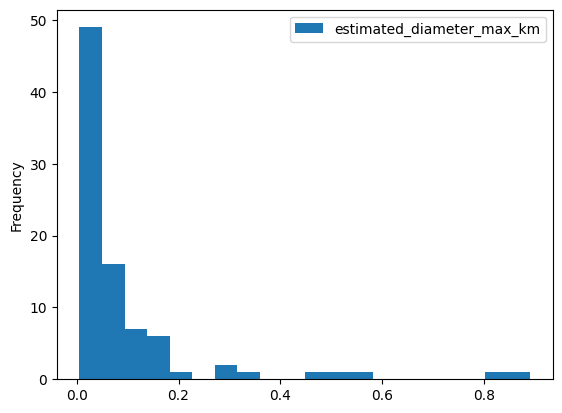

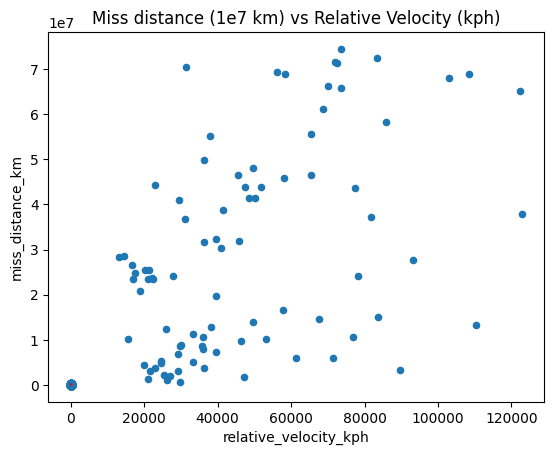

In [ ]:
%run ./main.ipynb

import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# print(df_all.size)


# print("First 10 rows of all data:")
# print(df_all.head(10).to_string())

# count of potentially hazardous asteroids (usually 0)
print("Number of asteroids marked as potentially hazardous:")
df_hazardous = df_all.query("is_potentially_hazardous_asteroid != 0")
print(df_hazardous.size)

# Near miss data table
df_near_miss = df_all.sort_values(by="miss_distance_km")
print("First 10 rows of near misses:")
print(df_near_miss.head(10).to_string())


# Histogram
print("Histogram of estimated diameter max in km:")
df_near_miss.plot.hist(column="estimated_diameter_max_km", bins=20)

# Scatter plot
print("Scatter plot of relative velocity vs. miss distance:")
df_near_miss.plot.scatter(title="Miss distance (1e7 km) vs Relative Velocity (kph)", x="relative_velocity_kph", y="miss_distance_km")

# turning the values into numpy arrays for linear regression
diam = np.array(df_all["estimated_diameter_max_km"])
miss = np.array(df_all["relative_velocity_kph"])

# linear regression with scipy
slope, intercept, r_value, p_value, std_err = stats.linregress(diam, miss)
plt.scatter(diam, miss)

# values for line of best fit (not working correctly)
x_line = np.sort(diam)
y_line = intercept + slope * x_line
plt.plot(x_line, y_line, 'r', label='fitted line')

